In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Machine Learning - Unsupervised Models
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

# Machine Learning - Metrics
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc,
    confusion_matrix, average_precision_score
)

# Dimensionality Reduction
from sklearn.manifold import TSNE

# Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Utilities
import time
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

print('All libraries imported successfully!')


All libraries imported successfully!


# =====================================================================

# Unsupervised Anomaly Detection — Binary Classification

# =====================================================================


This notebook applies **unsupervised learning** to detect anomalies in 5G network KPI data.
No labels are used during model training — the `anomaly` column is used **only as an oracle** during evaluation.

**Models:** Isolation Forest · Local Outlier Factor · One-Class SVM · Autoencoder (PyTorch)

**Evaluation:** Precision · Recall · F1-Score · AUC-ROC

**Visualisation:** PCA · t-SNE · UMAP *(optional)*


## 1. Data Loading

In [2]:
# Batch configuration
DATASET_PATH = Path('/Users/ayoubkallel/PFA2/-Intelligent-Anomaly-Monitoring-in-5G-networks/Data/Model_data.csv')
USE_BATCH_MODE = True
BATCH_SIZE = 50000
BATCH_NUMBER = 1  # 1 = first batch, 2 = second batch, ...

print('Batch configuration ready.')
print(f'  Dataset path : {DATASET_PATH}')
print(f'  Batch mode   : {USE_BATCH_MODE}')
if USE_BATCH_MODE:
    print(f'  Batch size   : {BATCH_SIZE:,}')
    print(f'  Batch number : {BATCH_NUMBER}')


Batch configuration ready.
  Dataset path : /Users/ayoubkallel/PFA2/-Intelligent-Anomaly-Monitoring-in-5G-networks/Data/Model_data.csv
  Batch mode   : True
  Batch size   : 50,000
  Batch number : 1


In [3]:
# Load the dataset or a specific batch
if USE_BATCH_MODE:
    total_rows = sum(1 for _ in DATASET_PATH.open('r', encoding='utf-8')) - 1
    start_row = (BATCH_NUMBER - 1) * BATCH_SIZE

    if start_row >= total_rows:
        raise ValueError(
            f'Batch {BATCH_NUMBER} is out of range. Dataset has {total_rows:,} data rows.'
        )

    rows_to_read = min(BATCH_SIZE, total_rows - start_row)
    df = pd.read_csv(DATASET_PATH, skiprows=range(1, start_row + 1), nrows=rows_to_read)
else:
    total_rows = sum(1 for _ in DATASET_PATH.open('r', encoding='utf-8')) - 1
    df = pd.read_csv(DATASET_PATH)

df['timestamp'] = pd.to_datetime(df['timestamp'])

print('✅ Dataset loaded successfully!')
print(f'📊 Loaded dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'📅 Period covered: {df["timestamp"].min()} to {df["timestamp"].max()}')
if USE_BATCH_MODE:
    print(f'📦 Active batch: {BATCH_NUMBER} | Rows: {start_row:,} to {start_row + len(df) - 1:,}')
else:
    print(f'📚 Full dataset loaded: {total_rows:,} rows')


✅ Dataset loaded successfully!
📊 Loaded dimensions: 50,000 rows × 20 columns
📅 Period covered: 2024-01-01 00:00:00 to 2024-06-22 14:35:00
📦 Active batch: 1 | Rows: 0 to 49,999


## 2. Data Overview

In [4]:
# Display first rows
print('First rows of the dataset:')
df.head(10)


First rows of the dataset:


,timestamp,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,rtt_ms,packet_delay_budget_ms,handover_interruption_time_ms,reliability_percent,packet_loss_percent,packet_loss_rate_percent,bler_percent,throughput_dl_mbps,throughput_ul_mbps,spectral_efficiency_bps_hz,handover_success_rate_percent,energy_efficiency_bits_per_joule,anomaly,anomaly_type
0,2024-01-01 00:00:00,URLLC,33.800386,-7.547638,2.5865,0.5029,5.3423,0.7614,5.2166,99.9995,0.0005,0.0005,0.4930,106.5463,103.6793,9.9301,99.5036,476587788.0,0,normal
1,2024-01-01 00:05:00,URLLC,33.802700,-7.553952,2.4543,0.4950,5.1841,0.7626,5.0939,99.9995,0.0005,0.0005,0.4954,102.3002,102.2863,9.9559,99.4860,485576369.0,0,normal
2,2024-01-01 00:10:00,URLLC,33.800517,-7.556512,2.4245,0.4927,5.1083,0.7753,5.1232,99.9995,0.0005,0.0005,0.4994,97.0391,98.8266,9.9911,99.4985,490452024.0,0,normal
3,2024-01-01 00:15:00,URLLC,33.803398,-7.559040,2.4348,0.4907,4.9188,0.7673,5.0829,99.9995,0.0005,0.0005,0.5044,96.8969,97.6382,10.0840,99.5141,506027291.0,0,normal
4,2024-01-01 00:20:00,URLLC,33.809118,-7.551471,2.3904,0.4889,5.0157,0.7729,5.0481,99.9995,0.0005,0.0005,0.5157,101.7346,98.3164,10.2236,99.5181,496323988.0,0,normal
5,2024-01-01 00:25:00,URLLC,33.794577,-7.554695,2.4409,0.5150,5.0458,0.7824,4.7151,99.9995,0.0005,0.0005,0.5139,96.4619,98.4923,10.2481,99.5385,489668796.0,0,normal
6,2024-01-01 00:30:00,URLLC,33.811347,-7.548111,2.3978,0.5055,5.2068,0.7816,4.7466,99.9995,0.0005,0.0005,0.5006,96.5526,98.1557,9.9963,99.5391,495385212.0,0,normal
7,2024-01-01 00:35:00,URLLC,33.801889,-7.553463,2.4210,0.5020,5.0116,0.7753,4.7985,99.9995,0.0005,0.0005,0.5288,98.0638,99.7111,9.9857,99.5064,496145255.0,0,normal
8,2024-01-01 00:40:00,URLLC,33.803297,-7.542945,2.4448,0.5391,5.0200,0.7750,4.8838,99.9995,0.0005,0.0005,0.5349,96.3044,104.3437,9.7772,99.5145,529736091.0,0,normal
9,2024-01-01 00:45:00,URLLC,33.798350,-7.545753,2.3878,0.5239,5.0687,0.7687,4.7361,99.9995,0.0005,0.0005,0.5141,101.7652,102.1902,9.7579,99.5253,508489425.0,0,normal


🚨 Anomaly distribution:
anomaly
0    48991
1     1009
Name: count, dtype: int64

   Normal   : 48,991 (97.98%)
   Anomalies: 1,009 (2.02%)

🔴 Anomaly types:
anomaly_type
signal_degradation    177
handover_failure      150
hardware_failure      140
interference          138
backhaul_issue        114
network_congestion    108
overload               92
security_attack        90
Name: count, dtype: int64


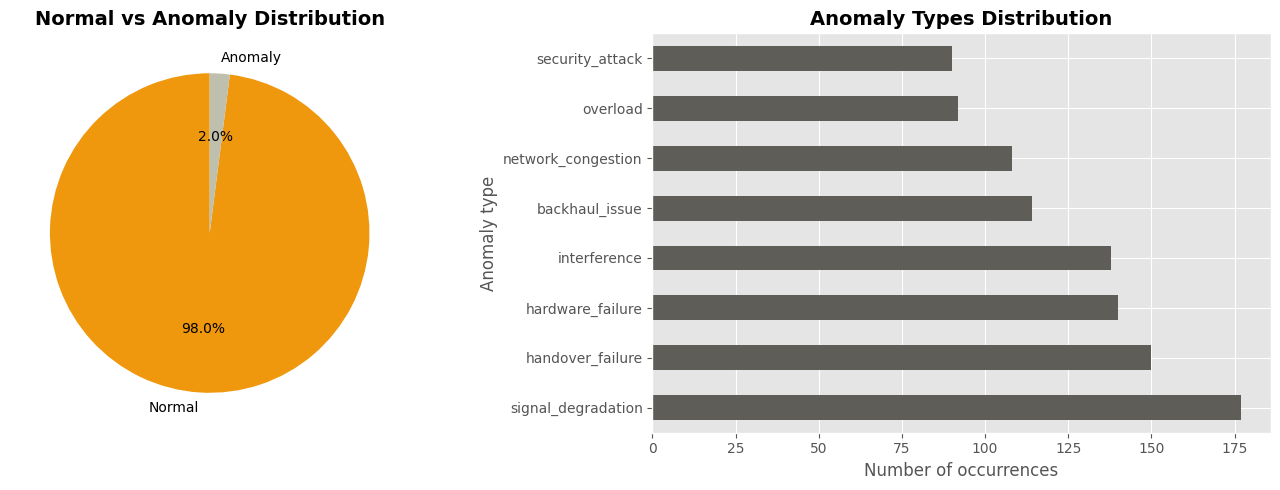

In [5]:
# Anomaly distribution
print('🚨 Anomaly distribution:')
anomaly_counts = df['anomaly'].value_counts()
print(anomaly_counts)
print(f'\n   Normal   : {anomaly_counts[0]:,} ({anomaly_counts[0]/len(df)*100:.2f}%)')
print(f'   Anomalies: {anomaly_counts[1]:,} ({anomaly_counts[1]/len(df)*100:.2f}%)')

print('\n🔴 Anomaly types:')
anomaly_types = df[df['anomaly'] == 1]['anomaly_type'].value_counts()
print(anomaly_types)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(anomaly_counts, labels=['Normal', 'Anomaly'], autopct='%1.1f%%',
            colors=['#ef980e', '#bfbfae'], startangle=90)
axes[0].set_title('Normal vs Anomaly Distribution', fontsize=14, fontweight='bold')

anomaly_types.plot(kind='barh', ax=axes[1], color='#5e5d58')
axes[1].set_title('Anomaly Types Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of occurrences')
axes[1].set_ylabel('Anomaly type')

plt.tight_layout()
plt.show()


# =====================================================================

# PREPROCESSING

# =====================================================================


## 3. Feature Engineering & Scaling

In [6]:
# =====================================================================
# 3.1 Extract temporal components from timestamp
# =====================================================================

df['year']      = df['timestamp'].dt.year
df['month']     = df['timestamp'].dt.month
df['day']       = df['timestamp'].dt.day
df['hour']      = df['timestamp'].dt.hour
df['minute']    = df['timestamp'].dt.minute
df['second']    = df['timestamp'].dt.second
df['dayofweek'] = df['timestamp'].dt.dayofweek

print('Temporal columns extracted:')
print(df[['timestamp', 'year', 'month', 'day', 'hour', 'minute', 'second', 'dayofweek']].head(5))


Temporal columns extracted:
            timestamp  year  month  day  hour  minute  second  dayofweek
0 2024-01-01 00:00:00  2024      1    1     0       0       0          0
1 2024-01-01 00:05:00  2024      1    1     0       5       0          0
2 2024-01-01 00:10:00  2024      1    1     0      10       0          0
3 2024-01-01 00:15:00  2024      1    1     0      15       0          0
4 2024-01-01 00:20:00  2024      1    1     0      20       0          0


In [7]:
# =====================================================================
# 3.2 Drop non-predictive identifier columns
# =====================================================================

columns_to_drop = []
df.drop(columns=columns_to_drop, inplace=True)

print(f'Dropped columns: {columns_to_drop}')
print(f'Note: timestamp will be excluded from features (X) during modeling.')
print(f'\nNew dataset dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'\nRemaining columns:\n{list(df.columns)}')


Dropped columns: []
Note: timestamp will be excluded from features (X) during modeling.

New dataset dimensions: 50,000 rows x 27 columns

Remaining columns:
['timestamp', 'slice_type', 'latitude', 'longitude', 'one_way_latency_ms', 'jitter_ms', 'rtt_ms', 'packet_delay_budget_ms', 'handover_interruption_time_ms', 'reliability_percent', 'packet_loss_percent', 'packet_loss_rate_percent', 'bler_percent', 'throughput_dl_mbps', 'throughput_ul_mbps', 'spectral_efficiency_bps_hz', 'handover_success_rate_percent', 'energy_efficiency_bits_per_joule', 'anomaly', 'anomaly_type', 'year', 'month', 'day', 'hour', 'minute', 'second', 'dayofweek']


In [8]:
# =====================================================================
# 3.3 Encode slice_type (Label Encoding)
# =====================================================================
# Only 3 categories (eMBB, URLLC, mMTC) -> Label Encoding is sufficient

le_slice = LabelEncoder()
df['slice_type'] = le_slice.fit_transform(df['slice_type'])

print('slice_type encoding (Label Encoding):')
for label, encoded in zip(le_slice.classes_, le_slice.transform(le_slice.classes_)):
    print(f'   {label} -> {encoded}')

print(f'\nDistribution after encoding:')
print(df['slice_type'].value_counts().sort_index())


slice_type encoding (Label Encoding):
   URLLC -> 0

Distribution after encoding:
slice_type
0    50000
Name: count, dtype: int64


In [9]:
# =====================================================================
# 3.4 Create clean copy & define features
# =====================================================================

df_clean = df.copy()

# Columns to exclude from features (labels kept aside as oracle)
exclude_cols = ['timestamp', 'anomaly', 'anomaly_type', 'year']
FEATURE_COLS = [c for c in df_clean.columns if c not in exclude_cols]

X = df_clean[FEATURE_COLS].values
y_true = df_clean['anomaly'].values     # oracle — NEVER passed to any model

print('='*70)
print('FEATURES / TARGETS SEPARATION')
print('='*70)
print(f'\n  Features (X): {len(FEATURE_COLS)} columns')
print(f'     {FEATURE_COLS}')
print(f'\n  Target (y_true): anomaly column')
print(f'     Classes: {sorted(np.unique(y_true).tolist())} -> 0=Normal, 1=Anomaly')
print(f'     Distribution: Normal={int((y_true==0).sum()):,}  Anomaly={int((y_true==1).sum()):,}')
print(f'     Anomaly rate: {y_true.mean()*100:.2f}%')


FEATURES / TARGETS SEPARATION

  Features (X): 23 columns
     ['slice_type', 'latitude', 'longitude', 'one_way_latency_ms', 'jitter_ms', 'rtt_ms', 'packet_delay_budget_ms', 'handover_interruption_time_ms', 'reliability_percent', 'packet_loss_percent', 'packet_loss_rate_percent', 'bler_percent', 'throughput_dl_mbps', 'throughput_ul_mbps', 'spectral_efficiency_bps_hz', 'handover_success_rate_percent', 'energy_efficiency_bits_per_joule', 'month', 'day', 'hour', 'minute', 'second', 'dayofweek']

  Target (y_true): anomaly column
     Classes: [0, 1] -> 0=Normal, 1=Anomaly
     Distribution: Normal=48,991  Anomaly=1,009
     Anomaly rate: 2.02%


In [10]:
# =====================================================================
# 3.5 StandardScaler — required by LOF, One-Class SVM, Autoencoder
# =====================================================================

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Separate normal data — used to train one-class models
normal_mask = (y_true == 0)
X_normal    = X_scaled[normal_mask]

print('='*70)
print('VERIFICATION — STEP 3')
print('='*70)
print(f'\n  X_scaled shape : {X_scaled.shape}')
print(f'  X_normal shape : {X_normal.shape}  (normal-only training set)')
print(f'\n  Mean (should be ~0): {X_scaled.mean():.6f}')
print(f'  Std  (should be ~1): {X_scaled.std():.6f}')


VERIFICATION — STEP 3

  X_scaled shape : (50000, 23)
  X_normal shape : (48991, 23)  (normal-only training set)

  Mean (should be ~0): -0.000000
  Std  (should be ~1): 0.955533


# =====================================================================

# UNSUPERVISED MODELS

# =====================================================================


> ⚠️ **Labels are never passed to any model during training.**
> The `anomaly` column is used **only in Section 5** as an evaluation oracle.


## 4. Unsupervised Detection Models

### 4.1 Isolation Forest

In [11]:
# =====================================================================
# 4.1 Isolation Forest
# =====================================================================
# Fits on the full dataset. Anomalies are isolated with shorter tree paths.

print('='*70)
print('ISOLATION FOREST')
print('='*70)

start_time = time.time()

iforest = IsolationForest(
    n_estimators  = 200,
    contamination = 'auto',
    max_samples   = 'auto',
    random_state  = 42,
    n_jobs        = -1
)
iforest.fit(X_scaled)
train_time_if = time.time() - start_time

# Scores: higher = more anomalous
scores_if = -iforest.decision_function(X_scaled)
preds_if  = (iforest.predict(X_scaled) == -1).astype(int)

print(f'\n  Training time      : {train_time_if:.1f}s')
print(f'  Flagged anomalies  : {preds_if.sum():,} ({preds_if.mean()*100:.2f}%)')
print(f'  Score range        : [{scores_if.min():.4f}, {scores_if.max():.4f}]')
print('\n✅ Isolation Forest done.')


ISOLATION FOREST

  Training time      : 0.3s
  Flagged anomalies  : 2,133 (4.27%)
  Score range        : [-0.1493, 0.2868]

✅ Isolation Forest done.


### 4.2 Local Outlier Factor (LOF)

In [12]:
# =====================================================================
# 4.2 Local Outlier Factor (LOF)
# =====================================================================
# Density-based: points in low-density regions relative to neighbours are outliers.

print('='*70)
print('LOCAL OUTLIER FACTOR (LOF)')
print('='*70)

start_time = time.time()

lof = LocalOutlierFactor(
    n_neighbors   = 20,
    contamination = 0.05,
    n_jobs        = -1
)
preds_lof_raw = lof.fit_predict(X_scaled)
train_time_lof = time.time() - start_time

scores_lof = -lof.negative_outlier_factor_    # higher = more anomalous
preds_lof  = (preds_lof_raw == -1).astype(int)

print(f'\n  Training time      : {train_time_lof:.1f}s')
print(f'  Flagged anomalies  : {preds_lof.sum():,} ({preds_lof.mean()*100:.2f}%)')
print(f'  Score range        : [{scores_lof.min():.4f}, {scores_lof.max():.4f}]')
print('\n✅ LOF done.')


LOCAL OUTLIER FACTOR (LOF)

  Training time      : 1.5s
  Flagged anomalies  : 2,500 (5.00%)
  Score range        : [0.9568, 2.3662]

✅ LOF done.


### 4.3 One-Class SVM

In [13]:
# =====================================================================
# 4.3 One-Class SVM
# =====================================================================
# Trained on normal data only — learns a tight hyperplane boundary.
# Note: subsampled for computational feasibility.

OCSVM_MAX_TRAIN = 10000

np.random.seed(42)
idx_ocsvm    = np.random.choice(len(X_normal), size=min(OCSVM_MAX_TRAIN, len(X_normal)), replace=False)
X_ocsvm_train = X_normal[idx_ocsvm]

print('='*70)
print('ONE-CLASS SVM')
print('='*70)
print(f'\n  Training on {len(X_ocsvm_train):,} normal samples (max={OCSVM_MAX_TRAIN:,})')

start_time = time.time()

ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
ocsvm.fit(X_ocsvm_train)
train_time_ocsvm = time.time() - start_time

scores_ocsvm = -ocsvm.decision_function(X_scaled)
preds_ocsvm  = (ocsvm.predict(X_scaled) == -1).astype(int)

print(f'  Training time      : {train_time_ocsvm:.1f}s')
print(f'  Flagged anomalies  : {preds_ocsvm.sum():,} ({preds_ocsvm.mean()*100:.2f}%)')
print(f'  Score range        : [{scores_ocsvm.min():.4f}, {scores_ocsvm.max():.4f}]')
print('\n✅ One-Class SVM done.')


ONE-CLASS SVM

  Training on 10,000 normal samples (max=10,000)
  Training time      : 0.3s
  Flagged anomalies  : 3,503 (7.01%)
  Score range        : [-30.8732, 19.9116]

✅ One-Class SVM done.


### 4.4 Autoencoder (PyTorch)

In [14]:
# =====================================================================
# 4.4.1 Autoencoder — Architecture
# =====================================================================
# Encoder: input -> 64 -> 32 -> 16 -> bottleneck(8)
# Decoder: 8 -> 16 -> 32 -> 64 -> input
# Trained on normal data only.
# Anomaly score = per-sample reconstruction error (MSE).

INPUT_DIM    = X_scaled.shape[1]
HIDDEN_DIMS  = [64, 32, 16]
BOTTLENECK   = 8
DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'

class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, bottleneck):
        super().__init__()
        # --- Encoder ---
        enc_layers = []
        prev = input_dim
        for h in hidden_dims:
            enc_layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU()]
            prev = h
        enc_layers.append(nn.Linear(prev, bottleneck))
        self.encoder = nn.Sequential(*enc_layers)
        # --- Decoder ---
        dec_layers = []
        prev = bottleneck
        for h in reversed(hidden_dims):
            dec_layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU()]
            prev = h
        dec_layers.append(nn.Linear(prev, input_dim))
        self.decoder = nn.Sequential(*dec_layers)

    def forward(self, x):
        return self.decoder(self.encoder(x))

ae = Autoencoder(INPUT_DIM, HIDDEN_DIMS, BOTTLENECK).to(DEVICE)

print('='*70)
print('AUTOENCODER — ARCHITECTURE')
print('='*70)
print(f'\n  Architecture : {INPUT_DIM} -> {HIDDEN_DIMS} -> {BOTTLENECK} -> {HIDDEN_DIMS[::-1]} -> {INPUT_DIM}')
print(f'  Parameters   : {sum(p.numel() for p in ae.parameters()):,}')
print(f'  Device       : {DEVICE}')


AUTOENCODER — ARCHITECTURE

  Architecture : 23 -> [64, 32, 16] -> 8 -> [16, 32, 64] -> 23
  Parameters   : 9,023
  Device       : cpu


AUTOENCODER — TRAINING

  Training samples : 48,991 (normal only)
  Epochs           : 40
  Batch size       : 512
  Learning rate    : 0.001

   Epoch 01/40  |  Loss: 0.287848  |  LR: 1.0e-03
   Epoch 10/40  |  Loss: 0.055403  |  LR: 1.0e-03
   Epoch 20/40  |  Loss: 0.044813  |  LR: 5.0e-04
   Epoch 30/40  |  Loss: 0.042129  |  LR: 2.5e-04
   Epoch 40/40  |  Loss: 0.040791  |  LR: 2.5e-04

✅ Training complete in 10.3s


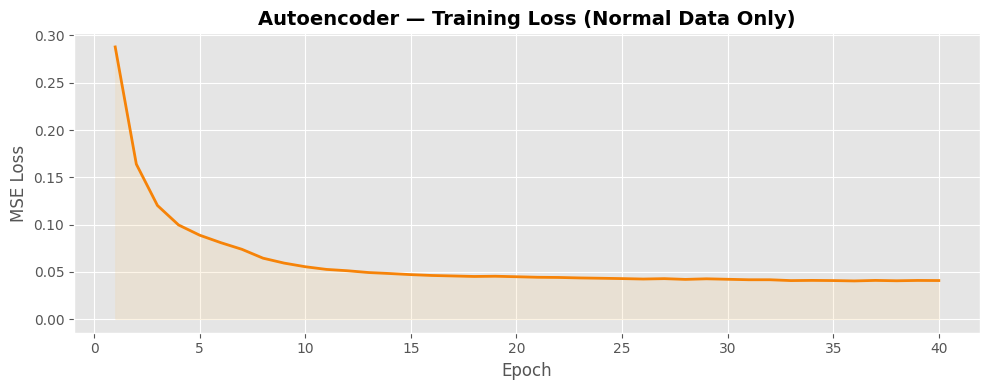

In [15]:
# =====================================================================
# 4.4.2 Autoencoder — Training
# =====================================================================

AE_EPOCHS     = 40
AE_BATCH_SIZE = 512
AE_LR         = 1e-3

loader    = DataLoader(
    TensorDataset(torch.tensor(X_normal, dtype=torch.float32)),
    batch_size=AE_BATCH_SIZE, shuffle=True
)
optimizer = torch.optim.Adam(ae.parameters(), lr=AE_LR)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)
losses    = []

print('='*70)
print('AUTOENCODER — TRAINING')
print('='*70)
print(f'\n  Training samples : {len(X_normal):,} (normal only)')
print(f'  Epochs           : {AE_EPOCHS}')
print(f'  Batch size       : {AE_BATCH_SIZE}')
print(f'  Learning rate    : {AE_LR}')
print()

ae.train()
start_time = time.time()

for epoch in range(1, AE_EPOCHS + 1):
    epoch_loss = 0.0
    for (batch,) in loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(ae(batch), batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch)
    epoch_loss /= len(X_normal)
    losses.append(epoch_loss)
    scheduler.step()
    if epoch % 10 == 0 or epoch == 1:
        current_lr = scheduler.get_last_lr()[0]
        print(f'   Epoch {epoch:02d}/{AE_EPOCHS}  |  Loss: {epoch_loss:.6f}  |  LR: {current_lr:.1e}')

train_time_ae = time.time() - start_time
print(f'\n✅ Training complete in {train_time_ae:.1f}s')

# --- Training loss curve ---
plt.figure(figsize=(10, 4))
plt.plot(range(1, AE_EPOCHS + 1), losses, color='#f68308', lw=2)
plt.fill_between(range(1, AE_EPOCHS + 1), losses, alpha=0.2, color='#F6CF8F')
plt.title('Autoencoder — Training Loss (Normal Data Only)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.tight_layout()
plt.show()


✅ Autoencoder inference complete.

  Threshold (95th pct of normal errors) : 0.092101
  Flagged anomalies                     : 3,334 (6.67%)


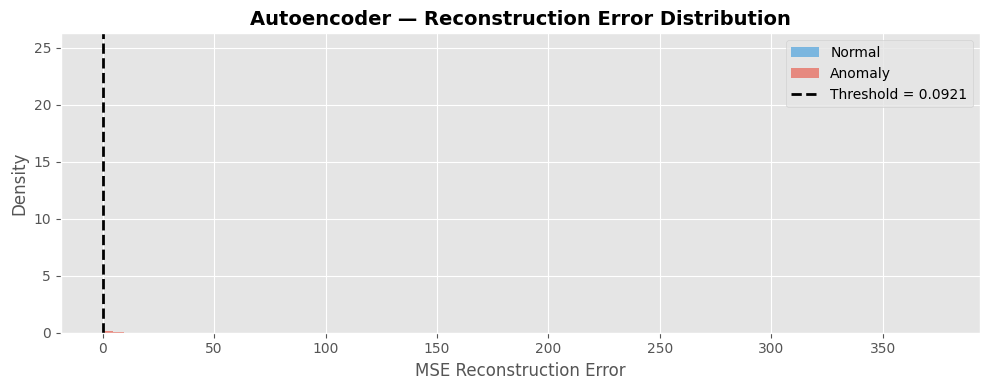

In [16]:
# =====================================================================
# 4.4.3 Autoencoder — Anomaly Scores
# =====================================================================
# Reconstruction error: normal samples -> low MSE, anomalies -> high MSE

ae.eval()
with torch.no_grad():
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(DEVICE)
    X_recon  = ae(X_tensor).cpu().numpy()

scores_ae    = np.mean((X_scaled - X_recon) ** 2, axis=1)

# Threshold: 95th percentile of normal sample reconstruction errors
threshold_ae = np.percentile(scores_ae[normal_mask], 95)
preds_ae     = (scores_ae > threshold_ae).astype(int)

print(f'✅ Autoencoder inference complete.')
print(f'\n  Threshold (95th pct of normal errors) : {threshold_ae:.6f}')
print(f'  Flagged anomalies                     : {preds_ae.sum():,} ({preds_ae.mean()*100:.2f}%)')

# --- Score distribution ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(scores_ae[normal_mask],  bins=80, color='#3498db', alpha=0.6, label='Normal',  density=True)
ax.hist(scores_ae[~normal_mask], bins=80, color='#e74c3c', alpha=0.6, label='Anomaly', density=True)
ax.axvline(threshold_ae, color='black', lw=2, ls='--', label=f'Threshold = {threshold_ae:.4f}')
ax.set_title('Autoencoder — Reconstruction Error Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('MSE Reconstruction Error')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()


# =====================================================================

# EVALUATION

# =====================================================================


## 5. Evaluation & Model Comparison

In [17]:
# =====================================================================
# 5.1 Per-model metrics — labels used as oracle here only
# =====================================================================

def compute_metrics(name, y_true, y_pred, scores):
    return {
        'Model'         : name,
        'Precision'     : precision_score(y_true, y_pred, zero_division=0),
        'Recall'        : recall_score(y_true, y_pred, zero_division=0),
        'F1-Score'      : f1_score(y_true, y_pred, zero_division=0),
        'AUC-ROC'       : roc_auc_score(y_true, scores),
        'Avg Precision' : average_precision_score(y_true, scores),
    }

results = [
    compute_metrics('Isolation Forest', y_true, preds_if,    scores_if),
    compute_metrics('LOF',              y_true, preds_lof,   scores_lof),
    compute_metrics('One-Class SVM',    y_true, preds_ocsvm, scores_ocsvm),
    compute_metrics('Autoencoder',      y_true, preds_ae,    scores_ae),
]

results_df = pd.DataFrame(results).set_index('Model').sort_values('F1-Score', ascending=False)

print('='*70)
print('UNSUPERVISED BINARY DETECTION — EVALUATION SUMMARY')
print('='*70)
print(results_df.to_string(float_format='{:.4f}'.format))
print()
print(f'🏆 Best model (F1)     : {results_df.index[0]}')
print(f'   Best F1-Score       : {results_df["F1-Score"].max():.4f}')
print(f'   Best AUC-ROC        : {results_df["AUC-ROC"].max():.4f}')


UNSUPERVISED BINARY DETECTION — EVALUATION SUMMARY
                  Precision  Recall  F1-Score  AUC-ROC  Avg Precision
Model                                                                
Isolation Forest     0.4135  0.8741    0.5614   0.9363         0.8244
Autoencoder          0.2651  0.8761    0.4071   0.9378         0.8203
One-Class SVM        0.2515  0.8731    0.3905   0.9353         0.8286
LOF                  0.0620  0.1536    0.0883   0.5385         0.0764

🏆 Best model (F1)     : Isolation Forest
   Best F1-Score       : 0.5614
   Best AUC-ROC        : 0.9378


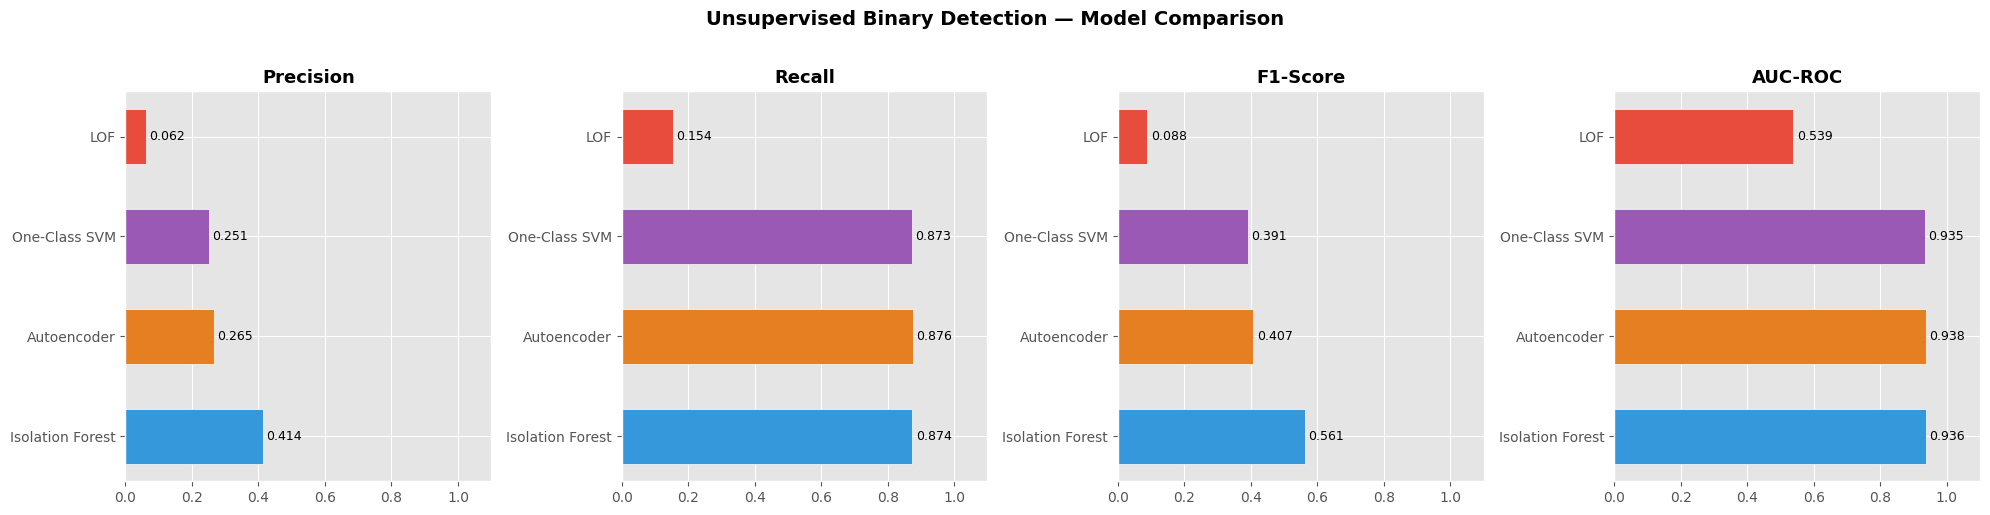

In [18]:
# =====================================================================
# 5.2 Bar chart — metric comparison across models
# =====================================================================

metrics_to_plot = ['Precision', 'Recall', 'F1-Score', 'AUC-ROC']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colors = ['#3498db', '#e67e22', '#9b59b6', '#e74c3c']

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.barh(results_df.index, results_df[metric], color=colors,
                   edgecolor='white', height=0.55)
    ax.set_xlim(0, 1.1)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    for bar, v in zip(bars, results_df[metric]):
        ax.text(v + 0.01, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Unsupervised Binary Detection — Model Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


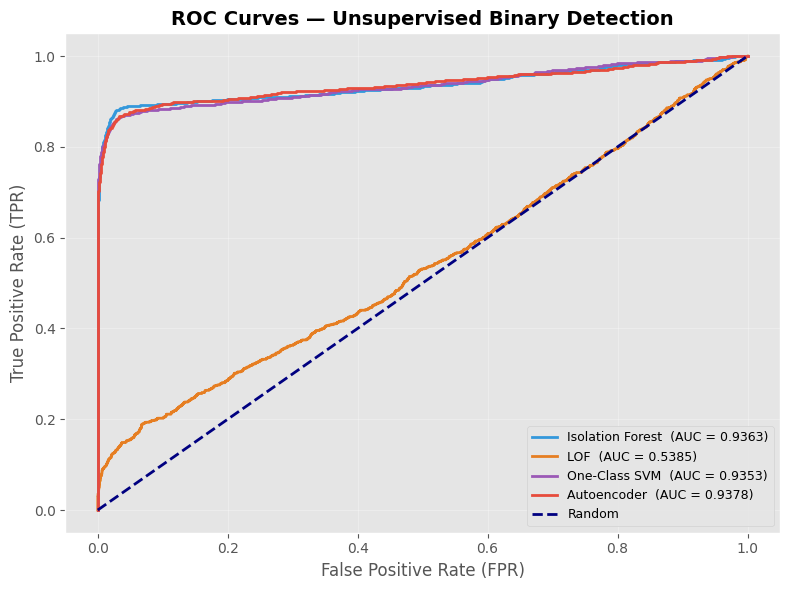

In [19]:
# =====================================================================
# 5.3 ROC curves — all models
# =====================================================================

model_scores = [
    ('Isolation Forest', scores_if),
    ('LOF',              scores_lof),
    ('One-Class SVM',    scores_ocsvm),
    ('Autoencoder',      scores_ae),
]
line_colors = ['#3498db', '#e67e22', '#9b59b6', '#e74c3c']

plt.figure(figsize=(8, 6))
for (name, scores), color in zip(model_scores, line_colors):
    fpr, tpr, _ = roc_curve(y_true, scores)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC = {roc_auc_val:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curves — Unsupervised Binary Detection', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


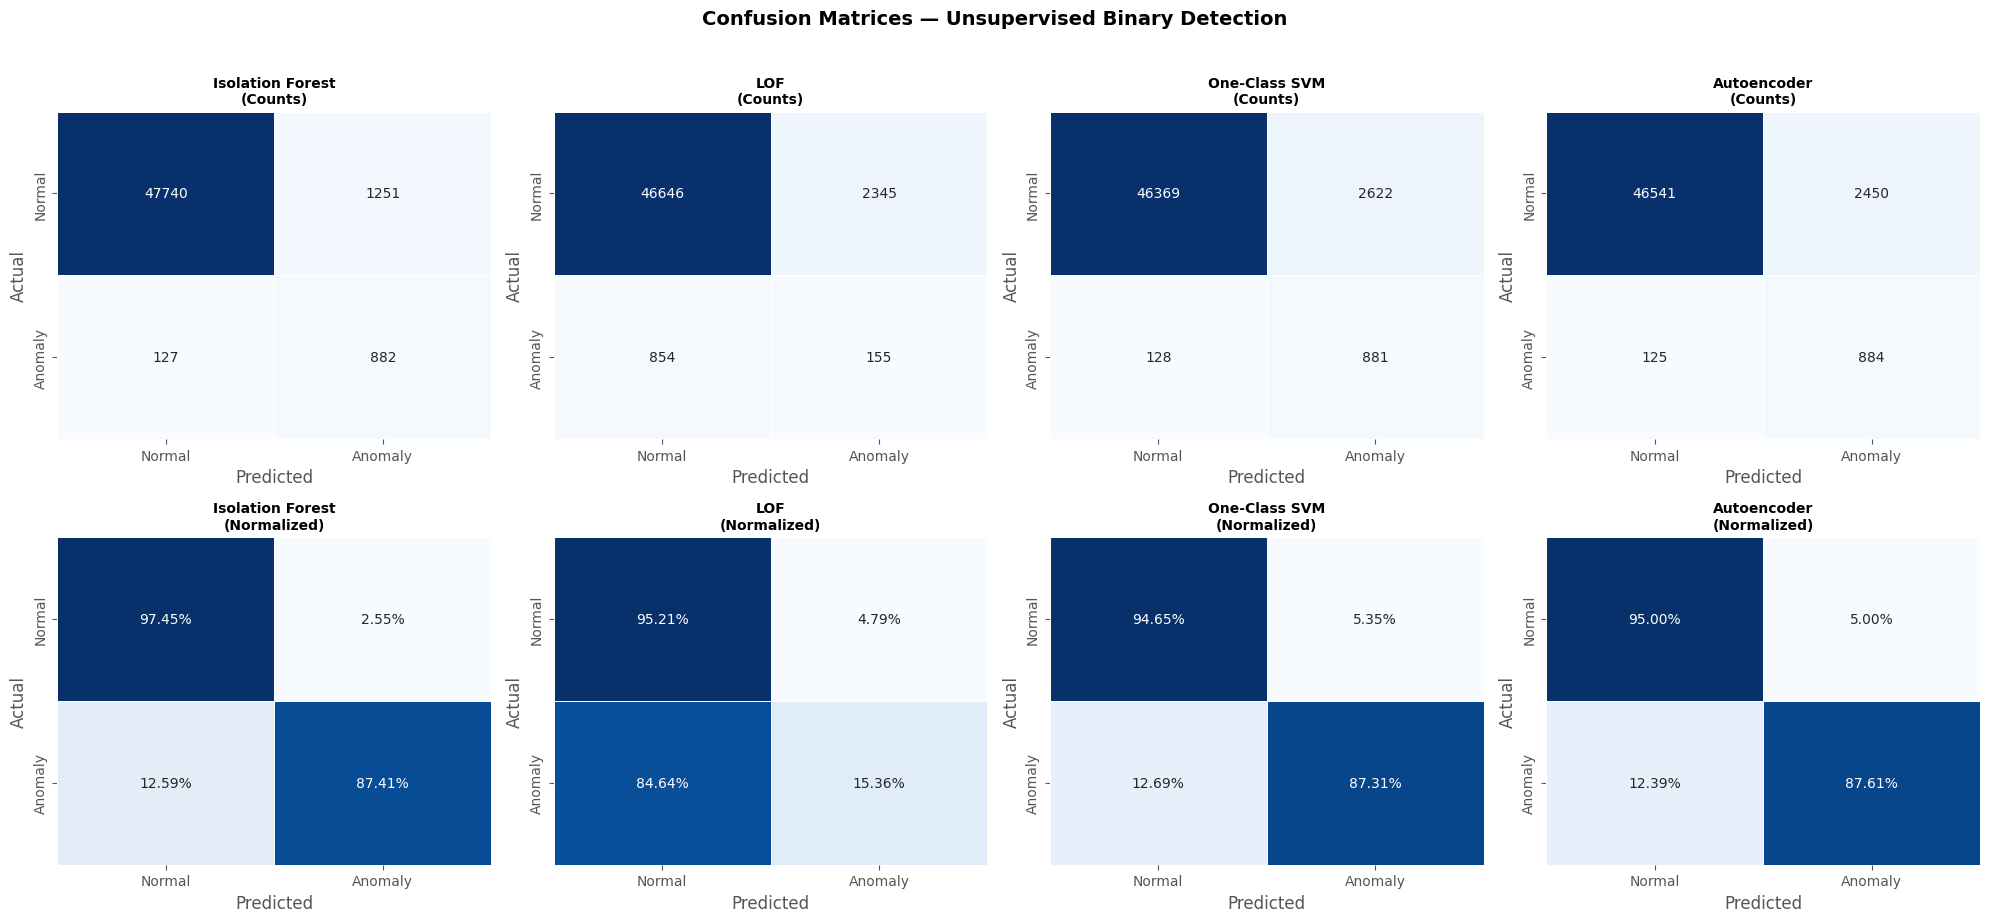

In [20]:
# =====================================================================
# 5.4 Confusion matrices — all models
# =====================================================================

all_preds = {
    'Isolation Forest' : preds_if,
    'LOF'              : preds_lof,
    'One-Class SVM'    : preds_ocsvm,
    'Autoencoder'      : preds_ae,
}

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for col, (name, preds) in enumerate(all_preds.items()):
    cm      = confusion_matrix(y_true, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Anomaly'],
                yticklabels=['Normal', 'Anomaly'],
                ax=axes[0, col], cbar=False, linewidths=0.5)
    axes[0, col].set_title(f'{name}\n(Counts)', fontsize=10, fontweight='bold')
    axes[0, col].set_xlabel('Predicted')
    axes[0, col].set_ylabel('Actual')

    # Normalized
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=['Normal', 'Anomaly'],
                yticklabels=['Normal', 'Anomaly'],
                ax=axes[1, col], cbar=False, linewidths=0.5)
    axes[1, col].set_title(f'{name}\n(Normalized)', fontsize=10, fontweight='bold')
    axes[1, col].set_xlabel('Predicted')
    axes[1, col].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Unsupervised Binary Detection',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# =====================================================================

# DIMENSIONALITY REDUCTION & VISUALISATION

# =====================================================================


## 6. Dimensionality Reduction & Visualisation

Each projection shows **true labels** (left column) vs **best-model predictions** (right column).
This lets us visually assess how well the unsupervised model separates anomalies from normal traffic.


In [21]:
# =====================================================================
# 6.0 Subsample for visualisation
# =====================================================================
# t-SNE and UMAP are slow on large datasets — we subsample for speed.

VIZ_SAMPLES = 5000
np.random.seed(42)
viz_idx   = np.random.choice(len(X_scaled), size=min(VIZ_SAMPLES, len(X_scaled)), replace=False)

X_viz     = X_scaled[viz_idx]
y_viz     = y_true[viz_idx]
BEST_MODEL = results_df.index[0]
pred_viz  = all_preds[BEST_MODEL][viz_idx]

print(f'📊 Visualisation sample : {len(viz_idx):,} points')
print(f'🏆 Best model (F1)      : {BEST_MODEL}')
print(f'   Anomaly rate in sample : {y_viz.mean()*100:.2f}%')


📊 Visualisation sample : 5,000 points
🏆 Best model (F1)      : Isolation Forest
   Anomaly rate in sample : 1.76%


### 6.1 PCA (Principal Component Analysis)

📊 PCA explained variance:
   PC1 : 26.5%
   PC2 : 12.7%
   Total : 39.2%


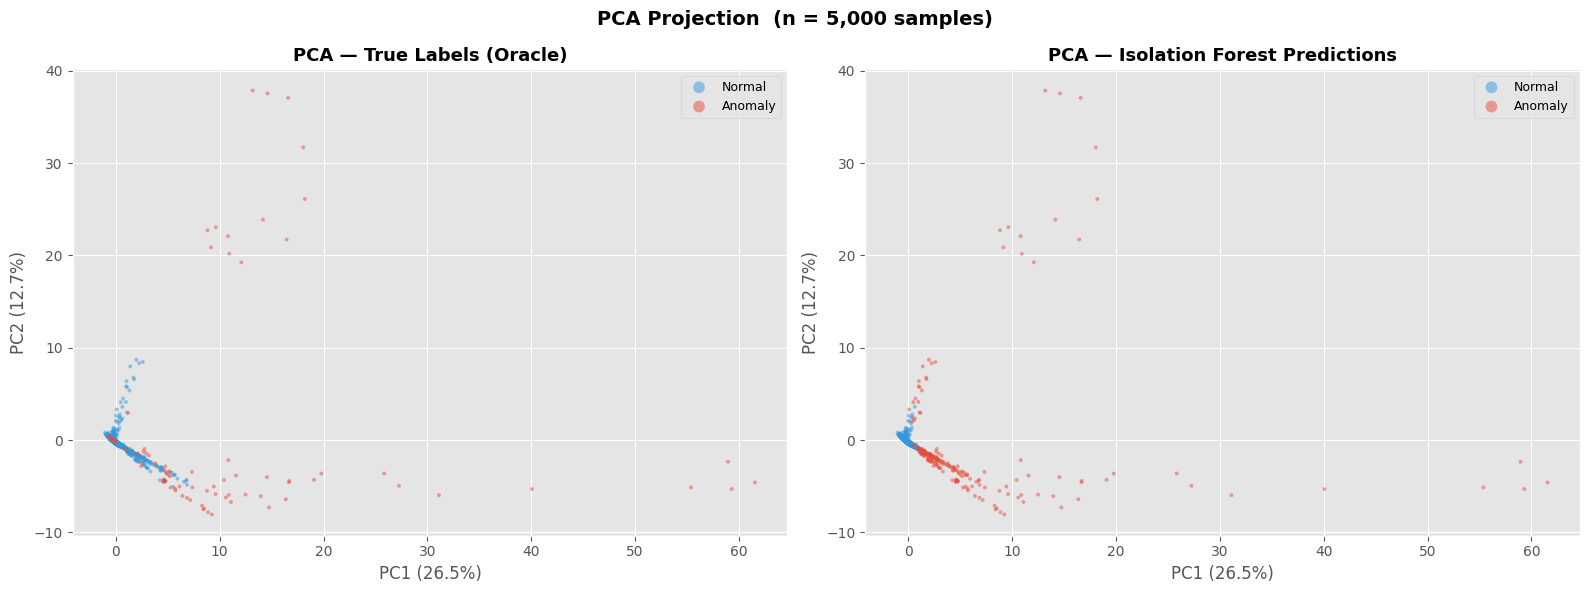

In [22]:
# =====================================================================
# 6.1 PCA — linear projection, fast
# =====================================================================

pca        = PCA(n_components=2, random_state=42)
coords_pca = pca.fit_transform(X_viz)
ev         = pca.explained_variance_ratio_

print(f'📊 PCA explained variance:')
print(f'   PC1 : {ev[0]*100:.1f}%')
print(f'   PC2 : {ev[1]*100:.1f}%')
print(f'   Total : {sum(ev)*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, labels, title in zip(
    axes,
    [y_viz, pred_viz],
    ['PCA — True Labels (Oracle)', f'PCA — {BEST_MODEL} Predictions']
):
    for val, label, color in zip([0, 1], ['Normal', 'Anomaly'], ['#3498db', '#e74c3c']):
        mask = labels == val
        ax.scatter(coords_pca[mask, 0], coords_pca[mask, 1],
                   c=color, s=8, alpha=0.5, label=label, edgecolors='none')
    ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(markerscale=3, fontsize=9)

plt.suptitle(f'PCA Projection  (n = {len(viz_idx):,} samples)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 6.2 t-SNE

⏳ Running t-SNE (this may take a few minutes)...
✅ t-SNE complete in 11.0s  |  KL divergence: 2.5365


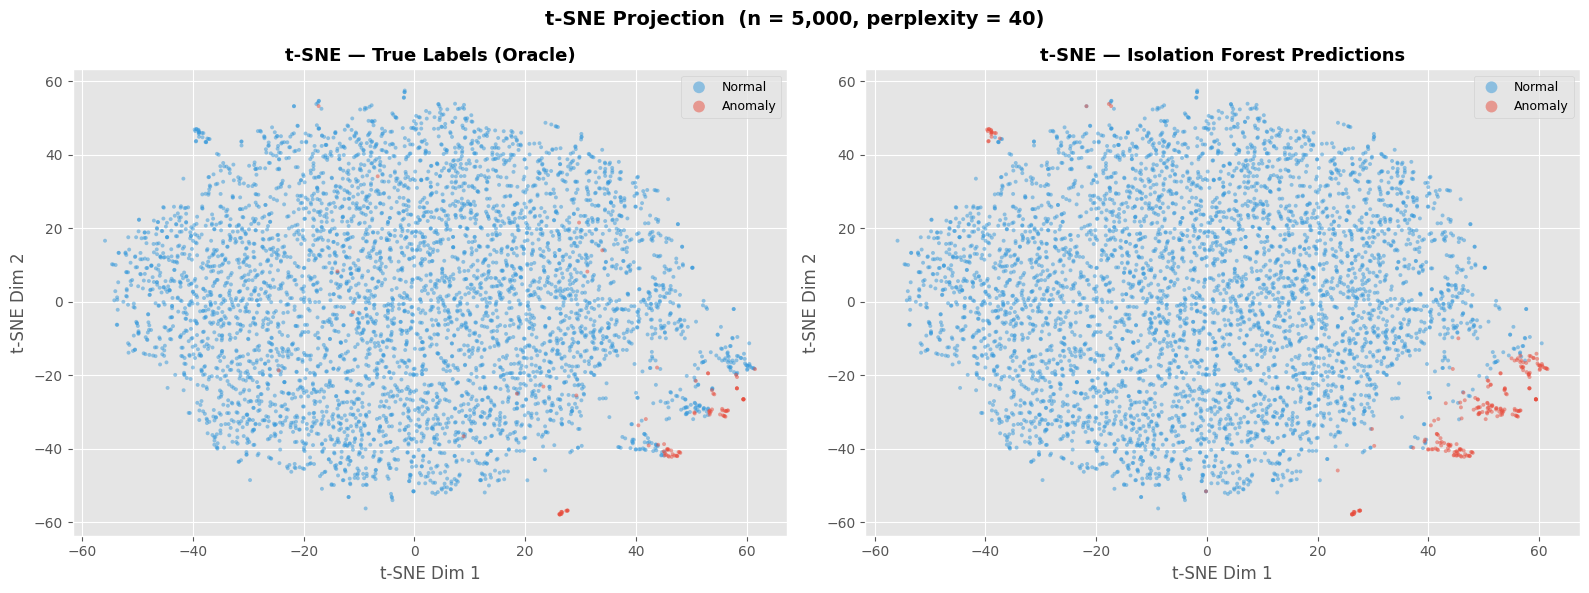

In [23]:
# =====================================================================
# 6.2 t-SNE — non-linear, reveals local cluster structure
# =====================================================================

print('⏳ Running t-SNE (this may take a few minutes)...')
start_time = time.time()

tsne        = TSNE(n_components=2, perplexity=40, n_iter=1000,
                   random_state=42, n_jobs=-1)
coords_tsne = tsne.fit_transform(X_viz)

print(f'✅ t-SNE complete in {time.time()-start_time:.1f}s  |  KL divergence: {tsne.kl_divergence_:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, labels, title in zip(
    axes,
    [y_viz, pred_viz],
    ['t-SNE — True Labels (Oracle)', f't-SNE — {BEST_MODEL} Predictions']
):
    for val, label, color in zip([0, 1], ['Normal', 'Anomaly'], ['#3498db', '#e74c3c']):
        mask = labels == val
        ax.scatter(coords_tsne[mask, 0], coords_tsne[mask, 1],
                   c=color, s=8, alpha=0.5, label=label, edgecolors='none')
    ax.set_xlabel('t-SNE Dim 1')
    ax.set_ylabel('t-SNE Dim 2')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(markerscale=3, fontsize=9)

plt.suptitle(f't-SNE Projection  (n = {len(viz_idx):,}, perplexity = 40)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 6.3 UMAP *(optional)*

In [24]:
# =====================================================================
# 6.3 UMAP — fast, preserves both local and global structure
# =====================================================================
# To enable: pip install umap-learn
# Then set USE_UMAP = True

USE_UMAP = False    # <- set to True if umap-learn is installed

if USE_UMAP:
    import umap
    print('⏳ Running UMAP...')
    start_time = time.time()

    reducer     = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
    coords_umap = reducer.fit_transform(X_viz)
    print(f'✅ UMAP complete in {time.time()-start_time:.1f}s')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, labels, title in zip(
        axes,
        [y_viz, pred_viz],
        ['UMAP — True Labels (Oracle)', f'UMAP — {BEST_MODEL} Predictions']
    ):
        for val, label, color in zip([0, 1], ['Normal', 'Anomaly'], ['#3498db', '#e74c3c']):
            mask = labels == val
            ax.scatter(coords_umap[mask, 0], coords_umap[mask, 1],
                       c=color, s=8, alpha=0.5, label=label, edgecolors='none')
        ax.set_xlabel('UMAP Dim 1')
        ax.set_ylabel('UMAP Dim 2')
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.legend(markerscale=3, fontsize=9)
    plt.suptitle(f'UMAP Projection  (n = {len(viz_idx):,})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('⚠️  UMAP skipped.')
    print('   To enable: pip install umap-learn  then set USE_UMAP = True above.')


⚠️  UMAP skipped.
   To enable: pip install umap-learn  then set USE_UMAP = True above.


# =====================================================================

# SUMMARY

# =====================================================================


## 7. Summary & Results

In [25]:
# =====================================================================
# 7. Final summary
# =====================================================================

print('='*70)
print('NOTEBOOK 1 — UNSUPERVISED BINARY DETECTION — FINAL RESULTS')
print('='*70)
print()
print(results_df.to_string(float_format='{:.4f}'.format))
print()
print('─'*70)
print(f'🏆 Best model (F1-Score) : {results_df.index[0]}')
print(f'   F1-Score              : {results_df["F1-Score"].max():.4f}')
print(f'   Precision             : {results_df.loc[results_df.index[0], "Precision"]:.4f}')
print(f'   Recall                : {results_df.loc[results_df.index[0], "Recall"]:.4f}')
print(f'   AUC-ROC               : {results_df.loc[results_df.index[0], "AUC-ROC"]:.4f}')
print('─'*70)
print()
print('📊 Training times:')
print(f'   Isolation Forest : {train_time_if:.1f}s')
print(f'   LOF              : {train_time_lof:.1f}s')
print(f'   One-Class SVM    : {train_time_ocsvm:.1f}s')
print(f'   Autoencoder      : {train_time_ae:.1f}s')


NOTEBOOK 1 — UNSUPERVISED BINARY DETECTION — FINAL RESULTS

                  Precision  Recall  F1-Score  AUC-ROC  Avg Precision
Model                                                                
Isolation Forest     0.4135  0.8741    0.5614   0.9363         0.8244
Autoencoder          0.2651  0.8761    0.4071   0.9378         0.8203
One-Class SVM        0.2515  0.8731    0.3905   0.9353         0.8286
LOF                  0.0620  0.1536    0.0883   0.5385         0.0764

──────────────────────────────────────────────────────────────────────
🏆 Best model (F1-Score) : Isolation Forest
   F1-Score              : 0.5614
   Precision             : 0.4135
   Recall                : 0.8741
   AUC-ROC               : 0.9363
──────────────────────────────────────────────────────────────────────

📊 Training times:
   Isolation Forest : 0.3s
   LOF              : 1.5s
   One-Class SVM    : 0.3s
   Autoencoder      : 10.3s
